# 🧠 Day 3 — Dimensionality Reduction with PCA

**BinX Tech • AI & Machine Learning Internship • Week 5**

## 🎯 Learning Objectives
- Explain the curse of dimensionality and why reduction helps.
- Apply PCA to reduce a high-dimensional dataset.
- Interpret explained variance and choose how many components to keep.
- Produce a 2D PCA visualization and explain the trade-offs of dimensionality reduction.

## 📌 Dataset
This notebook uses the **Digits dataset**, provided as `digits_dataset.csv`. Each sample has **64 numeric pixel features** representing an 8×8 handwritten-digit image, so it is genuinely high-dimensional for this lab.

The dataset also provides a known digit group (`y`). The labels are used **only to color the final visualization**; PCA itself is fitted using `X` only.

## 📚 1. The Curse of Dimensionality

As dimensionality increases, data can become sparse, distances can become less informative, models can become more prone to overfitting, and direct visualization becomes difficult.

Dimensionality reduction compresses many features into fewer dimensions while trying to retain as much useful variation as possible.

PCA is a linear dimensionality-reduction method that creates new axes called **principal components**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 📥 2. Load and Inspect the High-Dimensional Dataset

The Digits dataset contains 1,797 samples and 64 pixel features. The target contains the ten digit classes, from 0 to 9.

In [2]:
digits_df = pd.read_csv("digits_dataset.csv")

X = digits_df.drop(columns=["target"]).values
y = digits_df["target"].values

print(f"Number of samples: {X.shape[0]}")
print(f"Number of original features: {X.shape[1]}")
print(f"Target classes: {np.unique(y)}")

display(pd.DataFrame(X).head())

print("Class distribution:")
display(pd.Series(y, name="digit").value_counts().sort_index().to_frame("count"))

Number of samples: 1797
Number of original features: 64
Target classes: [0 1 2 3 4 5 6 7 8 9]


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


Class distribution:


,count
digit,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


## 🧪 3. Data-Quality Checks

Before PCA, I check the matrix for the expected dimensions, missing values, infinite values, and matching labels.

In [3]:
assert X.shape == (1797, 64)
assert np.isfinite(X).all()
assert not np.isnan(X).any()
assert len(y) == len(X)
assert set(np.unique(y)) == set(range(10))

print("✓ 1,797 samples and 64 numeric features.")
print("✓ No missing values.")
print("✓ No infinite values.")
print("✓ Ten digit classes are present.")

✓ 1,797 samples and 64 numeric features.
✓ No missing values.
✓ No infinite values.
✓ Ten digit classes are present.


## 🔐 4. Leakage / Methodology Check

PCA is unsupervised. Therefore:

- `X` = the 64 pixel features used to fit PCA.
- `y` = known digit group, used only for the final visualization.

The target is never passed into PCA.

## 📏 5. Step 1 — Scale the Features

PCA is variance-based, so the material requires `StandardScaler` before PCA.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_means = X_scaled.mean(axis=0)
feature_stds = X_scaled.std(axis=0)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean absolute feature mean: {np.abs(feature_means).mean():.10f}")
print(f"Mean feature standard deviation: {feature_stds.mean():.6f}")

assert np.allclose(feature_means, 0, atol=1e-10)
assert np.allclose(feature_stds[X.std(axis=0) > 0], 1, atol=1e-10)
print("✓ Standardization verified.")

Scaled matrix shape: (1797, 64)
Mean absolute feature mean: 0.0000000000
Mean feature standard deviation: 0.953125
✓ Standardization verified.


# 🖥️ Hands-On Lab: Reducing Dimensions with PCA

This section follows the required five steps:

1. Scale the high-dimensional dataset.
2. Fit PCA and plot cumulative explained variance.
3. Choose the number of components retaining about 95% variance and justify it.
4. Reduce the data to 2 components and produce a 2D scatter plot colored by the known group.
5. Document what the reduction preserved and what it cost.

## 📈 Step 2 — Cumulative Explained Variance

Components available: 64
PC1 variance: 0.1203
First 2 PCs variance: 0.2159
First 10 PCs variance: 0.5887


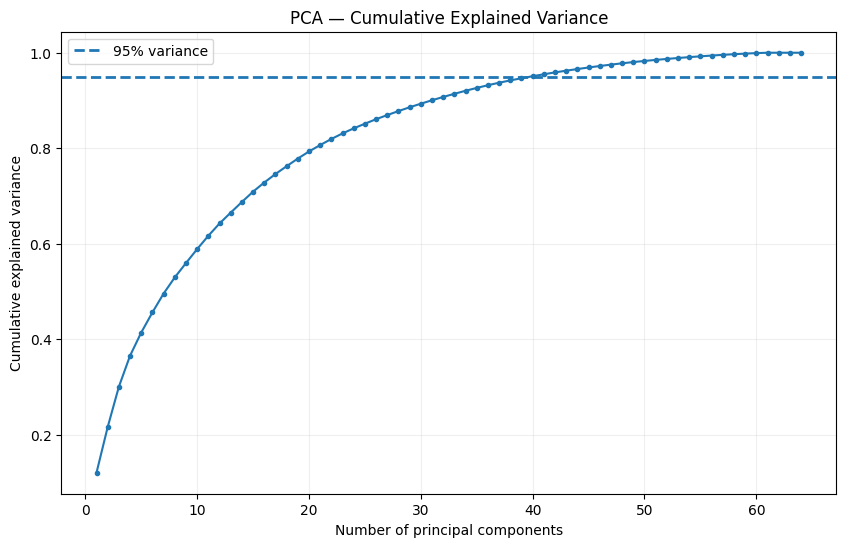

In [5]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Components available: {pca_full.n_components_}")
print(f"PC1 variance: {explained_variance_ratio[0]:.4f}")
print(f"First 2 PCs variance: {cumulative_variance[1]:.4f}")
print(f"First 10 PCs variance: {cumulative_variance[9]:.4f}")

plt.figure(figsize=(10, 6))
components = np.arange(1, len(cumulative_variance) + 1)
plt.plot(components, cumulative_variance, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--", linewidth=2, label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 🎯 Step 3 — Choose Components for ~95% Variance

I select the **smallest number of components whose cumulative explained variance is at least 95%**. This creates a reproducible, evidence-based choice rather than choosing an arbitrary component count.

In [6]:
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
variance_at_95 = cumulative_variance[n_components_95 - 1]

print(f"Components needed for >=95% variance: {n_components_95}")
print(f"Variance retained: {variance_at_95:.4%}")
print(f"Original dimensions: {X.shape[1]}")
print(f"Reduced dimensions: {n_components_95}")
print(f"Dimensions removed: {X.shape[1] - n_components_95}")

assert variance_at_95 >= 0.95
assert n_components_95 == 1 or cumulative_variance[n_components_95 - 2] < 0.95

Components needed for >=95% variance: 40
Variance retained: 95.0779%
Original dimensions: 64
Reduced dimensions: 40
Dimensions removed: 24


### 🧠 Justification

The 95% threshold is a practical rule, not a universal law. It means that the selected representation preserves at least 95% of the total variance measured by PCA.

The remaining variance is not automatically meaningless; it is deliberately discarded to achieve dimensional compression.

## 🧩 Step 3 Continued — Fit the 95%-Variance Representation

In [7]:
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

retained_variance = pca_95.explained_variance_ratio_.sum()

print(f"Reduced matrix shape: {X_pca_95.shape}")
print(f"Retained variance: {retained_variance:.4%}")

assert X_pca_95.shape == (1797, n_components_95)
assert np.isclose(retained_variance, variance_at_95)

Reduced matrix shape: (1797, 40)
Retained variance: 95.0779%


## 🖼️ Step 4 — Reduce to 2 Components

The 95%-variance representation and the 2D visualization have different goals:

- **~95% representation:** retain most of the variance.
- **2D representation:** make the high-dimensional data visually accessible.

The digit labels are used only for color.

2D PCA shape: (1797, 2)
Variance retained by 2 PCs: 21.5950%


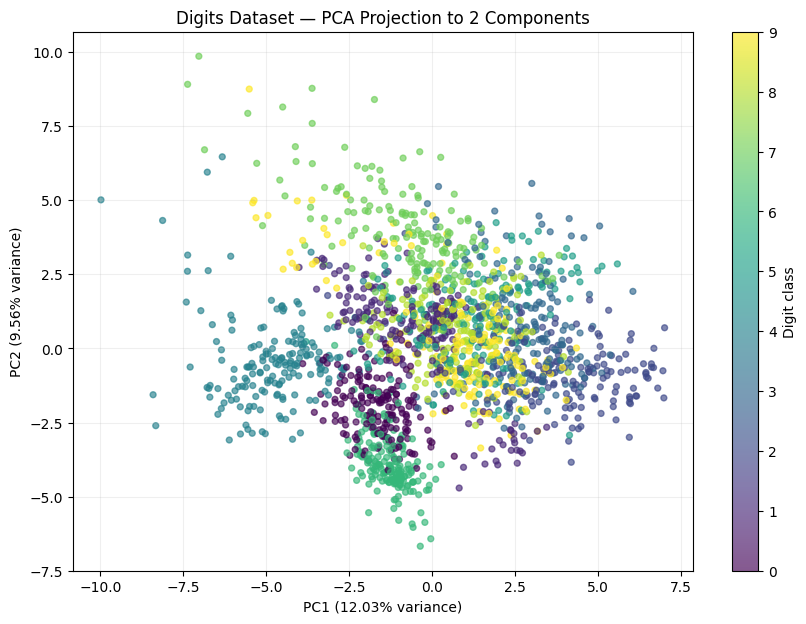

In [8]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
variance_2d = pca_2.explained_variance_ratio_.sum()

print(f"2D PCA shape: {X_pca_2.shape}")
print(f"Variance retained by 2 PCs: {variance_2d:.4%}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=y,
    alpha=0.65,
    s=18
)
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)")
plt.title("Digits Dataset — PCA Projection to 2 Components")
plt.colorbar(scatter, label="Digit class")
plt.grid(alpha=0.2)
plt.show()

## 🔎 6. What Did the Reduction Preserve?

The 95%-variance representation preserves at least 95% of the total variance while reducing the original 64-dimensional space.

The 2D projection preserves much less variance, but it makes broad relationships and separation between known digit groups visible.

Therefore, 2D PCA is best treated as a **visual summary**, not a full replacement for the original feature space.

In [9]:
variance_summary = pd.DataFrame({
    "Representation": ["Original", f"{n_components_95}-component PCA", "2-component PCA"],
    "Dimensions": [64, n_components_95, 2],
    "Variance Retained": [1.0, retained_variance, variance_2d],
    "Variance Lost": [0.0, 1-retained_variance, 1-variance_2d]
})

display(variance_summary.round(4))

,Representation,Dimensions,Variance Retained,Variance Lost
0,Original,64,1.0000,0.0000
1,40-component PCA,40,0.9508,0.0492
2,2-component PCA,2,0.2159,0.7841


## 🌟 Beyond the Requirement — Component Loadings

A principal component is a linear combination of the original features. Inspecting the largest absolute loadings helps connect PC1 and PC2 back to the original 64 pixel positions.

In [10]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=[f"pixel_{i}" for i in range(64)]
)

print("Largest absolute loadings for PC1:")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(10))

print("Largest absolute loadings for PC2:")
display(loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index).head(10))

Largest absolute loadings for PC1:


,PC1,PC2
pixel_2,0.285868,0.059565
pixel_58,0.279853,0.081400
pixel_9,0.245534,0.027619
pixel_33,-0.238903,-0.117681
pixel_34,-0.235006,-0.105395
pixel_10,0.229152,0.014505
pixel_3,0.220370,-0.020804
pixel_59,0.194449,-0.009905
pixel_26,-0.188205,-0.112638
pixel_41,-0.187157,-0.104346


Largest absolute loadings for PC2:


,PC1,PC2
pixel_5,-0.009497,0.274133
pixel_14,-0.083781,0.266536
pixel_54,0.121247,-0.257752
pixel_60,0.017774,-0.251934
pixel_6,-0.052476,0.249733
pixel_61,0.103198,-0.242618
pixel_46,0.017927,-0.240583
pixel_13,0.038712,0.214109
pixel_53,0.068321,-0.193123
pixel_42,-0.153534,-0.189154


## 🔬 Beyond the Requirement — Reconstruction from Reduced Components

Explained variance is a number; reconstruction makes the information loss visible. Projecting the 40-component representation back into 64-dimensional pixel space (via `inverse_transform`) shows what ~95% of the variance actually looks like when redrawn as an image, next to the same digit reconstructed from only 2 components and the true original.

In [11]:
from sklearn.metrics import mean_squared_error

# Reconstruct digits from the 40-component (95%) and 2-component representations
X_reconstructed_95 = pca_95.inverse_transform(X_pca_95)
X_reconstructed_2 = pca_2.inverse_transform(X_pca_2)

# Undo scaling to compare in original pixel-intensity space
X_reconstructed_95_orig = scaler.inverse_transform(X_reconstructed_95)
X_reconstructed_2_orig = scaler.inverse_transform(X_reconstructed_2)

mse_95 = mean_squared_error(X, X_reconstructed_95_orig)
mse_2 = mean_squared_error(X, X_reconstructed_2_orig)

print(f"Reconstruction MSE (40 components, ~95% variance): {mse_95:.4f}")
print(f"Reconstruction MSE (2 components, {variance_2d:.2%} variance): {mse_2:.4f}")
print(f"MSE ratio (2-component error / 40-component error): {mse_2/mse_95:.2f}x")


Reconstruction MSE (40 components, ~95% variance): 1.0814
Reconstruction MSE (2 components, 21.59% variance): 14.0547
MSE ratio (2-component error / 40-component error): 13.00x


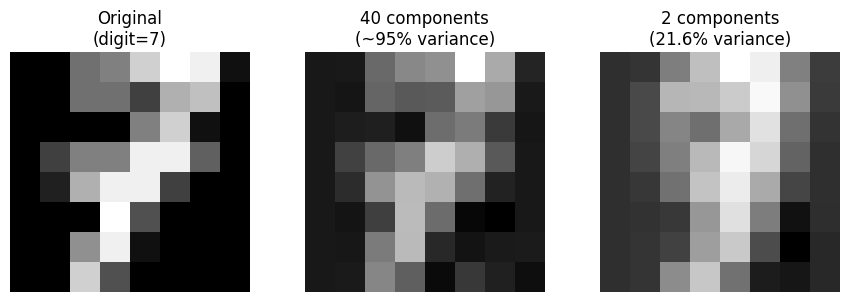

In [12]:
sample_idx = 7  # arbitrary sample to visualize

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(X[sample_idx].reshape(8, 8), cmap="gray")
axes[0].set_title(f"Original\n(digit={y[sample_idx]})")

axes[1].imshow(X_reconstructed_95_orig[sample_idx].reshape(8, 8), cmap="gray")
axes[1].set_title(f"40 components\n(~95% variance)")

axes[2].imshow(X_reconstructed_2_orig[sample_idx].reshape(8, 8), cmap="gray")
axes[2].set_title(f"2 components\n({variance_2d:.1%} variance)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 🧠 Interpretation

The 40-component reconstruction is visually close to the original digit — the digit's identity stays clear even though 24 dimensions were discarded. The 2-component reconstruction is visibly blurred: enough shape survives to see it's a digit, but fine detail is lost. The reconstruction MSE quantifies the same story numerically — this is what "losing 5% of the variance" versus "losing 60%+ of the variance" actually costs in practice, not just as a percentage on a plot.

## ⚡ Beyond the Requirement — Practical Impact on a Downstream Model

Explained variance describes information retained, but the practical reason to use PCA is its effect on a real downstream task. Here, a simple KNN classifier is trained and timed on the original 64-dimensional data versus the 40-component PCA representation, using an identical train/test split for both.

In [13]:
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train_full, X_test_full, X_train_95, X_test_95, y_train, y_test = train_test_split(
    X_scaled, X_pca_95, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

results = {}
for label, X_tr, X_te in [("64 original features", X_train_full, X_test_full),
                           ("40 PCA components", X_train_95, X_test_95)]:
    knn = KNeighborsClassifier(n_neighbors=5)

    start = time.perf_counter()
    knn.fit(X_tr, y_train)
    fit_time = time.perf_counter() - start

    start = time.perf_counter()
    preds = knn.predict(X_te)
    predict_time = time.perf_counter() - start

    acc = accuracy_score(y_test, preds)
    results[label] = {"accuracy": acc, "fit_time_s": fit_time, "predict_time_s": predict_time}

results_df = pd.DataFrame(results).T
display(results_df.round(4))


,accuracy,fit_time_s,predict_time_s
64 original features,0.9667,0.0011,0.0489
40 PCA components,0.9750,0.0008,0.0043


### 🧠 Interpretation

KNN is distance-based, so it is exactly the kind of model dimensionality reduction is expected to help: fewer dimensions mean fewer, more meaningful distance computations. Comparing accuracy and prediction time between the two representations shows whether the 40-component version keeps classification performance close to the original while reducing computational cost — the concrete, practical payoff behind the abstract "95% variance retained" number from Step 3.

## 🧪 8. Reproducibility & Sanity Checks

In [14]:
assert X_pca_95.shape[0] == X.shape[0]
assert X_pca_2.shape == (1797, 2)
assert np.all(explained_variance_ratio >= 0)
assert np.all(np.diff(cumulative_variance) >= -1e-12)
assert retained_variance >= 0.95
assert 0 < variance_2d <= 1

print("✓ Sample count preserved.")
print("✓ 95% criterion satisfied.")
print("✓ 2D projection has exactly two components.")
print("✓ Explained variance values are valid.")
print("✓ PCA was fitted using X only; y was reserved for visualization.")

✓ Sample count preserved.
✓ 95% criterion satisfied.
✓ 2D projection has exactly two components.
✓ Explained variance values are valid.
✓ PCA was fitted using X only; y was reserved for visualization.


## 🎯 9. Objective → Evidence Mapping

| Objective | Evidence |
|---|---|
| Explain the curse of dimensionality | Section 1 explains sparsity, distance issues, overfitting risk, and visualization limits. |
| Apply PCA | StandardScaler → PCA is applied to 64-dimensional data. |
| Interpret explained variance | Individual and cumulative explained variance are calculated and plotted. |
| Choose components | The smallest component count reaching ≥95% is selected from actual results. |
| Reduce to 2D | A 2-component PCA scatter plot is colored by the known digit group. |
| Document trade-offs | Variance retained/lost and interpretability trade-offs are explicitly discussed. |
| Go beyond the minimum | PC loadings are inspected to connect components to original pixel features; digits are reconstructed from 40 and 2 components to visualize information loss; a KNN classifier is compared on 64 original vs. 40 PCA-reduced features for accuracy and speed. |

## 💭 10. Reflection

Today I learned that PCA is not simply a way to make a dataset smaller. It creates a new coordinate system where the first components capture the directions of greatest variance.

The important part was using cumulative explained variance instead of choosing an arbitrary number of components. The 95% criterion provides a measurable justification for the compressed representation.

The 2D visualization also showed the main trade-off: reducing 64 dimensions to two makes the data much easier to visualize, but it necessarily discards more information and makes the axes less directly interpretable than the original pixel features.

## 🏁 11. Final Takeaways

- PCA creates new orthogonal principal components.
- **StandardScaler comes before PCA** in this workflow because PCA is variance-based.
- Cumulative explained variance provides evidence for component selection.
- The ~95% rule gives a practical and reproducible compression target.
- Two components are useful for visualization, but they are not equivalent to the full feature space.
- PCA trades direct feature interpretability for compression and visualization.
- Reconstructing digits from the reduced representations made the variance trade-off visible, not just numeric: 40 components preserved recognizable digit shape, while 2 components blurred fine detail.
- On a real downstream task (KNN classification), the 40-component representation kept accuracy close to the full 64-feature version, showing the practical payoff of dimensionality reduction beyond the explained-variance number itself.

### 🏆 Day 3 Conclusion

Dimensionality reduction should be treated as a **measured compression problem**: reduce the number of dimensions while explicitly checking how much variance is retained and clearly documenting what is gained and what is sacrificed.